In [21]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Subindo um nível para sair de 'notebooks' e entrando em 'data' para pegar o CSV
df = pd.read_csv('../data/dataset_manutencao_estagio.csv')

# Checagem dos dados do Case 2
df.head()

,id_maquina,tipo_maquina,horas_uso,temperatura_celsius,vibracao_mm_s,pressao_psi,falha_estado
0,1,Tipo_C,7674,67.43,2.88,94.60,0
1,2,Tipo_A,1789,84.36,1.54,NaN,0
2,3,Tipo_C,3367,71.84,2.83,102.69,0
3,4,Tipo_C,7733,73.98,2.10,76.64,0
4,5,Tipo_A,4506,75.33,2.65,86.58,0


In [22]:
# 1. Resumo estatístico das variáveis numéricas
print("--- Resumo Estatístico ---")
display(df.describe())

# 2. Informações de tipos de dados e contagem de não-nulos
print("\n--- Informações do Dataset ---")
display(df.info())

# 3. Proporção variável alvo (falha_estado) para checar balanceamento
print("\n--- Distribuição das Falhas (0 = Normal, 1 = Falha) ---")
print(df['falha_estado'].value_counts(normalize=True) * 100)

--- Resumo Estatístico ---


,id_maquina,horas_uso,temperatura_celsius,vibracao_mm_s,pressao_psi,falha_estado
count,2500.00000,2500.000000,2450.000000,2500.000000,2470.000000,2500.000000
mean,1250.50000,4077.677200,70.317653,2.537496,100.127219,0.042000
std,721.83216,2256.029277,8.792786,0.617529,12.045462,0.200629
min,1.00000,106.000000,44.590000,0.890000,52.930000,0.000000
25%,625.75000,2145.500000,64.480000,2.150000,92.295000,0.000000
50%,1250.50000,4006.500000,70.115000,2.490000,100.085000,0.000000
75%,1875.25000,6025.250000,75.467500,2.850000,108.120000,0.000000
max,2500.00000,7998.000000,106.640000,5.530000,140.530000,1.000000



--- Informações do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_maquina           2500 non-null   int64  
 1   tipo_maquina         2500 non-null   str    
 2   horas_uso            2500 non-null   int64  
 3   temperatura_celsius  2450 non-null   float64
 4   vibracao_mm_s        2500 non-null   float64
 5   pressao_psi          2470 non-null   float64
 6   falha_estado         2500 non-null   int64  
dtypes: float64(3), int64(3), str(1)
memory usage: 136.8 KB


None


--- Distribuição das Falhas (0 = Normal, 1 = Falha) ---
falha_estado
0    95.8
1     4.2
Name: proportion, dtype: float64


In [23]:
#limpeza e tratamento dos valores

#cópia original dos dados
df_clean = df.copy()

mediana_temperatura = df_clean['temperatura_celsius'].median()
mediana_pressao = df_clean['pressao_psi'].median()


#substituir pela mediana os valoers null
df_clean['temperatura_celsius'] = df_clean['temperatura_celsius'].fillna(mediana_temperatura)
df_clean['pressao_psi'] = df_clean['pressao_psi'].fillna(mediana_pressao)

print("--- Validação do Tratamento de Nulos ---")
print(f"Valores nulos em Temperatura: {df_clean['temperatura_celsius'].isna().sum()}")
print(f"Valores nulos em Pressão: {df_clean['pressao_psi'].isna().sum()}")

--- Validação do Tratamento de Nulos ---
Valores nulos em Temperatura: 0
Valores nulos em Pressão: 0


In [24]:
#tipo maquina so recebe A B C D ...
#preciso converter para numéricos

df_clean = pd.get_dummies(df_clean, columns=['tipo_maquina'], drop_first=True)

df_clean.head()

,id_maquina,horas_uso,temperatura_celsius,vibracao_mm_s,pressao_psi,falha_estado,tipo_maquina_Tipo_B,tipo_maquina_Tipo_C
0,1,7674,67.43,2.88,94.600,0,False,True
1,2,1789,84.36,1.54,100.085,0,False,False
2,3,3367,71.84,2.83,102.690,0,False,True
3,4,7733,73.98,2.10,76.640,0,False,True
4,5,4506,75.33,2.65,86.580,0,False,False


In [25]:
# Verificando quais colunas existem agora no df_clean
df_clean.columns

Index(['id_maquina', 'horas_uso', 'temperatura_celsius', 'vibracao_mm_s',
       'pressao_psi', 'falha_estado', 'tipo_maquina_Tipo_B',
       'tipo_maquina_Tipo_C'],
      dtype='str')

In [28]:
import sys
!{sys.executable} -m pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 3.6 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 1.4 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [29]:
from sklearn.model_selection import train_test_split


#sensores e tipos de maquina
X = df_clean.drop(columns=['id_maquina', 'falha_estado'])

#modelo aprendedor 
y = df_clean['falha_estado']

#proporção clássica de 20% e 80%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print(f"Linhas para o treino do modelo: {X_train.shape[0]}")
print(f"Linhas para o teste de validação: {X_test.shape[0]}")
print(f"Número de características (sensores): {X_train.shape[1]}")

Linhas para o treino do modelo: 2000
Linhas para o teste de validação: 500
Número de características (sensores): 6


In [30]:
from sklearn.ensemble import RandomForestClassifier
# Escolhi o Random Forest porque ele trata bem variáveis muito diferentes
# hora vs vibração -> não foi necessáiria normalização e tendo também o parâmetro class_wheight = balenced
# Árvores de decisão capturam relações não-lineares complexas entre os sensores



#equilibrar o peso das falhas 
modelo_manutencao = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

#dados de treino (X_train e y_train)
modelo_manutencao.fit(X_train, y_train)

#momento de teste do modelo
predicoes = modelo_manutencao.predict(X_test)

print("--- Modelo Treinado com Sucesso! ---")
print("As previsões para o conjunto de teste já foram geradas.")

--- Modelo Treinado com Sucesso! ---
As previsões para o conjunto de teste já foram geradas.


--- Relatório de Classificação do Modelo ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       479
           1       0.95      1.00      0.98        21

    accuracy                           1.00       500
   macro avg       0.98      1.00      0.99       500
weighted avg       1.00      1.00      1.00       500



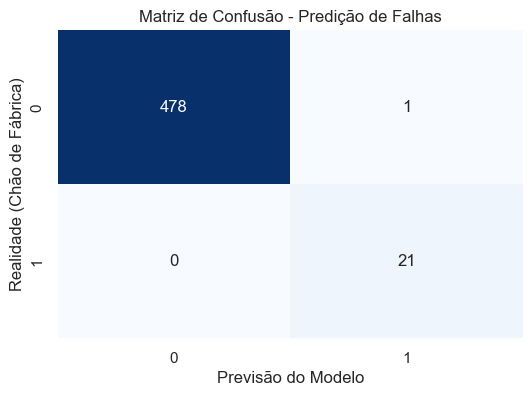

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Relatório de Classificação do Modelo ---")
print(classification_report(y_test, predicoes))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, predicoes), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Predição de Falhas')
plt.ylabel('Realidade (Chão de Fábrica)')
plt.xlabel('Previsão do Modelo')
plt.show()